In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('./datasets/students_results.csv')
df.head()

,marks,attendance,result
0,0.37,0.05,0
1,0.95,0.53,1
2,0.73,0.54,1
3,0.60,0.64,1
4,0.16,0.73,0


In [3]:
X = df[['marks', 'attendance']].values
y = df['result'].values

X_train = X[:250]
y_train = y[:250]
X_test = X[250:]
y_test = y[250:]

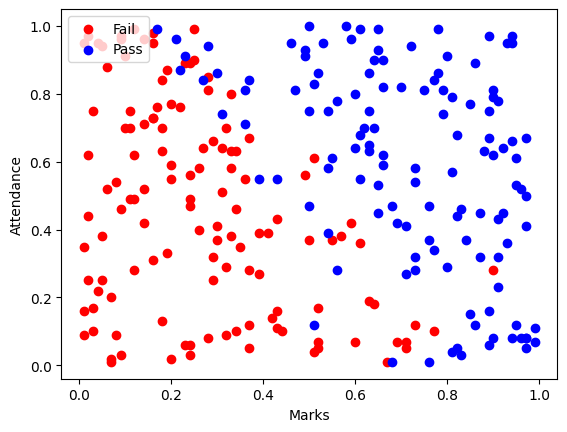

In [4]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', label='Fail')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='blue', label='Pass')
plt.xlabel('Marks')
plt.ylabel('Attendance')
plt.legend(loc='upper left')
plt.show()

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
def cost_function(X,y,w,b):
    m = X.shape[0]
    cost_sum = 0

    for i in range(m):
        z = np.dot(X[i], w) + b
        g = sigmoid(z)

        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
    
    return (1/m) * cost_sum

In [7]:
def gradient_function(X,y,w,b):
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(X[i], w) + b
        g = sigmoid(z)

        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i,j]

    grad_b  = (1/m) * grad_b
    grad_w = (1/m) * grad_w

    return grad_b, grad_w

In [9]:
def predict(X,w,b):
    m = X.shape[0]
    y_pred = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        y_pred[i] = 1 if g >= 0.5 else 0

    return y_pred

In [ ]:
def gradient_descent(X, y,alpha,epochs):
    m, n = X.shape
    w = np.zeros(n)
    b = 0

    for i in range(epochs):
        grad_b, grad_w = gradient_function(X,y,w,b)

        w -= alpha * grad_w
        b -= alpha * grad_b

        if i % 100 == 0:
            cost = cost_function(X,y,w,b)
            predictions = predict(X_test, w, b)
            accuracy = np.mean(predictions == y_test) * 100
            print(f"Epoch: {i} | Cost: {cost} | Accuracy: {accuracy}%")

    return w,b

In [16]:
learning_rate = 0.06
epochs = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, epochs)

predictions = predict(X_test, final_w, final_b)
accuracy = np.mean(predictions == y_test) * 100
print(f"Testing Accuracy: {accuracy:.2f}%") 

Epoch: 0 | Cost: 0.6923518274586954 | Accuracy: 50.0%
Epoch: 100 | Cost: 0.6354471702770169 | Accuracy: 66.0%
Epoch: 200 | Cost: 0.5920858616119679 | Accuracy: 76.0%
Epoch: 300 | Cost: 0.5559927233478726 | Accuracy: 78.0%
Epoch: 400 | Cost: 0.5256474351849745 | Accuracy: 80.0%
Epoch: 500 | Cost: 0.49988839701008364 | Accuracy: 82.0%
Epoch: 600 | Cost: 0.4778116708913408 | Accuracy: 82.0%
Epoch: 700 | Cost: 0.45871480746605575 | Accuracy: 82.0%
Epoch: 800 | Cost: 0.44205050805362 | Accuracy: 82.0%
Epoch: 900 | Cost: 0.4273900852456019 | Accuracy: 82.0%
Epoch: 1000 | Cost: 0.41439541381331657 | Accuracy: 82.0%
Epoch: 1100 | Cost: 0.4027976882046836 | Accuracy: 84.0%
Epoch: 1200 | Cost: 0.3923814230604303 | Accuracy: 84.0%
Epoch: 1300 | Cost: 0.3829724085309092 | Accuracy: 84.0%
Epoch: 1400 | Cost: 0.3744286183412171 | Accuracy: 84.0%
Epoch: 1500 | Cost: 0.3666333142646397 | Accuracy: 84.0%
Epoch: 1600 | Cost: 0.3594897850033067 | Accuracy: 84.0%
Epoch: 1700 | Cost: 0.3529173049117934 | A

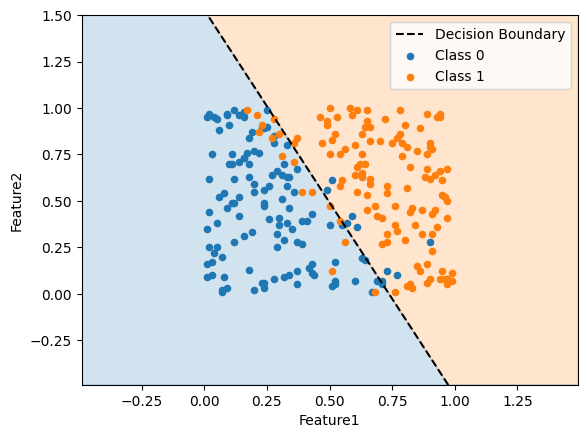

In [11]:
m = -final_w[0] / final_w[1]
c = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xd = np.array([xmin, xmax])
yd = m * xd + c

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary' )
plt.fill_between(xd, yd, ymin, color='tab:blue', alpha=0.2)
plt.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.2)

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:orange', label='Class 1', s=20)
plt. legend ()
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt. show()